In [ ]:
# %pip install keras==2.13.1
# %pip install tensorflow==2.13.0
# %pip install pandas
# %pip install scipy
# %pip install statsmodels
# %pip install scikit-learn
# %pip install seaborn
# %pip install matplotlib
# %pip install keyboard

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 24.8 MB/s  0:00:07m0:00:0100:01
  Attempting uninstall: tensorflow-macos
    Found existing installation: tensorflow-macos 2.13.1
    Uninstalling tensorflow-macos-2.13.1:━━━━━━━ 0/2 [tensorflow-macos]
      Successfully uninstalled tensorflow-macos-2.13.10/2 [tensorflow-macos]
  Attempting uninstall: tensorflow━━━━━━━━━━━━━━ 0/2 [tensorflow-macos]
    Found existing installation: tensorflow 2.13.10/2 [tensorflow-macos]
    Uninstalling tensorflow-2.13.1:━━━━━━━━━ 0/2 [tensorflow-macos]
      Successfully uninstalled tensorflow-2.13.1 0/2 [tensorflow-macos]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]s]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import pickle
import random
import time
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
import sys

from statsmodels.tsa.ar_model import AutoReg

import keras
print("Keras version:", keras.__version__)
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
from tensorflow.keras.backend import clear_session
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPool1D, Flatten, Dropout
from tensorflow.keras.layers import Activation, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as rect

import bit_wise_data_prep_v2 as bit_wise_data_prep
import synthetic_tag_meas
import bit_wise_classes
import testing_utilities
from visualization import make_confusion_matrix

/Users/maxhilding/Documents/Programming/Projects/ExplainThisPage/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Keras version: 2.13.1
TensorFlow version: 2.13.0


## Function Definitions and Model Layers

In [5]:
def min_max_norm(X_abs):
    Min = X_abs.min(axis=1)
    Min = Min.reshape(Min.shape + (1,))

    Max = X_abs.max(axis=1)
    Max = Max.reshape(Max.shape + (1,))

    X_abs_norm = (X_abs - Min) / (Max - Min)

    return X_abs_norm

In [6]:
def plot_random(X_to_use, codes_to_use, freq, freq_limits, xlim=[2.8, 7.3]):
    idx = random.randint(0, X_to_use.shape[0]-1)
    #print(idx)
    _, ax = plt.subplots(figsize=(10,6))

    ax.plot(freq/10**9, X_to_use[idx])

    for vline in freq_limits[1:-1]:
        ax.axvline(vline/10**9, color='black')
        ax.axvline(vline/10**9, color='black')

    ax.set_xlim(xlim)
    ax.set_title(codes_to_use[idx])

    return idx

In [7]:
#@keras.saving.get_custom_objects().clear()
@keras.saving.register_keras_serializable(package='Norm')
class SegmentNormalizeLayer(tf.keras.layers.Layer):
    def __init__(self, freq, freq_limits, normalize_index, **kwargs):
        super(SegmentNormalizeLayer, self).__init__(**kwargs)
        # Convert freq to a TensorFlow constant tensor
        self.freq = tf.constant(freq, dtype=tf.float32)
        # Convert freq_limits to a TensorFlow constant tensor
        self.freq_limits = tf.constant(freq_limits, dtype=tf.float32)
        self.normalize_index = normalize_index

    def call(self, inputs):
        n_segments = len(self.freq_limits) - 1
        outputs = []
        for i in range(n_segments):
            # Find start and end indices using TensorFlow operations
            start = tf.where(tf.equal(self.freq, self.freq_limits[i]))[0][0]
            end = tf.where(tf.equal(self.freq, self.freq_limits[i+1]))[0][0]
            segment = inputs[:, start:end, :]

            # Apply normalization only on the specified index in the last dimension
            normalized_segment = tf.concat([
                (segment[:, :, j:j+1] - tf.reduce_min(segment[:, :, j:j+1], axis=1, keepdims=True)) /
                (tf.reduce_max(segment[:, :, j:j+1], axis=1, keepdims=True) - tf.reduce_min(segment[:, :, j:j+1], axis=1, keepdims=True))
                if j == self.normalize_index else segment[:, :, j:j+1]
                for j in range(segment.shape[-1])
            ], axis=-1)

            outputs.append(normalized_segment)

        output = tf.concat(outputs, axis=1)
        output.set_shape([inputs.shape[0], inputs.shape[1] - 1, inputs.shape[2]]) #the dynamic process is complex.
                        #The output shape will not be define until the freq and freq_limits are actually explore through
                        #call method. It is thus necessary to specified explicitly the outshape (because we can infered it)
        return output

    def compute_output_shape(self, input_shape):
        # Assuming the input shape is preserved except for the segmentation
        return (input_shape[0], input_shape[1] - 1, input_shape[2])

    def get_config(self):
        base_config = super().get_config()
        config = {
            'freq': keras.saving.serialize_keras_object(self.freq),
            'freq_limits': keras.saving.serialize_keras_object(self.freq_limits),
            'normalize_index': self.normalize_index
        }

        return {**base_config, **config}
        '''
        config = super(SegmentNormalizeLayer, self).get_config()
        config.update({
            'freq': self.freq.numpy(),#.tolist(),  # Convert tensor to list for JSON serialization
            'freq_limits': self.freq_limits.numpy(),#.tolist(),
            'normalize_index': self.normalize_index
        })
        return config'''

    @classmethod
    def from_config(cls, config):
        freq_config = config.pop('freq')
        freq = keras.saving.deserialize_keras_object(freq_config)
        freq_limits_config = config.pop('freq_limits')
        freq_limits = keras.saving.deserialize_keras_object(freq_limits_config)
        normalize_index_config = config.pop('normalize_index')
        normalize_index = normalize_index_config

        return cls(freq, freq_limits, normalize_index, **config)

In [8]:
@keras.saving.register_keras_serializable(package='Selection')
class SelectiveDenseLayer(tf.keras.layers.Layer):
    def __init__(self, units, freq, freq_limits, **kwargs):
        super(SelectiveDenseLayer, self).__init__(**kwargs)
        self.units = units
        self.freq = np.array(freq).reshape(-1, 1)
        self.freq_limits = freq_limits
        self.positions = np.abs(self.freq - self.freq_limits).argmin(axis=0)

    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(input_shape[-1], self.units),
                                      initializer='uniform',
                                      trainable=True)
        self.bias = self.add_weight(shape=(self.units,),
                                    initializer='zeros',
                                    trainable=True)

        # Calculate proportionality for selective connection
        n = input_shape[-1]
        m = len(self.freq)
        start = int((self.positions[0] / m) * n)
        end = int((self.positions[1] / m) * n)

        # Calculate indices using TensorFlow to ensure they are tensors
        start = tf.cast(tf.math.round((self.positions[0] / m) * n), tf.int32)
        end = tf.cast(tf.math.round((self.positions[1] / m) * n), tf.int32)

        # Create a mask using TensorFlow operations
        self.mask = tf.Variable(initial_value=tf.zeros((n, self.units)), trainable=False, dtype=tf.float32)
        indices = tf.range(n, dtype=tf.int32)
        mask_values = tf.where((indices >= start) & (indices < end), 1.0, 0.0)
        self.mask.assign(tf.tile(tf.expand_dims(mask_values, axis=-1), [1, self.units]))

    def call(self, inputs):
        masked_kernel = self.kernel * self.mask
        #return masked_kernel
        return tf.matmul(inputs, masked_kernel) + self.bias

    def compute_output_shape(self):
        return self.units

    def get_config(self):
        base_config = super().get_config()
        config = {
            'units': self.units,
            'freq': keras.saving.serialize_keras_object(self.freq),
            'freq_limits': keras.saving.serialize_keras_object(self.freq_limits)
        }

        return {**base_config, **config}
        '''
        config.update({
            'units': self.units,
            'freq': self.freq.tolist(),
            'freq_limits': self.freq_limits.tolist(),
        })
        return config'''

    @classmethod
    def from_config(cls, config):
        units_config = config.pop('units')
        units = units_config
        freq_config = config.pop('freq')
        freq = keras.saving.deserialize_keras_object(freq_config)
        freq_limits_config = config.pop('freq_limits')
        freq_limits = keras.saving.deserialize_keras_object(freq_limits_config)

        return cls(units, freq, freq_limits, **config)

In [9]:
def set_axis(ax, fontsize=12, fontweight='bold', legend=True, xlabel='Predicted label', ylabel='True label', tick_size=12):

    ax.set_xlabel(xlabel, fontsize=fontsize, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
    ax.tick_params(axis='both', which='both', labelsize=tick_size)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    if legend:
        legend = ax.legend(fontsize=12)
        plt.setp(legend.get_texts(), fontweight='bold')

In [10]:
init_dir = os.getcwd()

## Data Preperation

In [ ]:
path = './raw_data/ref'
X_ref, codes_ref, _, intervals_ref, freq = bit_wise_data_prep.real_all_tags_in_folder(reading_path=path)
X_complex_ref = X_ref[:,:,0] + 1j*X_ref[:,:,1]
X_complex_ref = X_complex_ref.reshape(X_complex_ref.shape + (1,))

os.chdir(init_dir)

y_ref = [np.array([int(i) for i in code]) for code in codes_ref]
y_ref = np.array(y_ref)

X_abs_ref = np.absolute(X_complex_ref)
X_norm_ref = min_max_norm(X_abs_ref)

FileNotFoundError: [Errno 2] No such file or directory: '/trial_3/ref'

## Define Freq_limits

In [46]:
#dropping the first part of the signals (2.8 to 2.9 GHz)
idx_start = np.where(freq==2.9*10**9)[0][0]
freq_limits = np.array([2.9, 3.3, 3.7, 4.2, 4.7, 5.3]) * 10**9

## Continue Data Prep

In [10]:
idx_to_show = np.isin(codes_ref, ['10011', '11100', '00101', '01010'])

exp_freqs = np.array([2.9535, 3.5077, 4.0551, 4.5295, 4.8959]) * 10**9

freq_limits = np.array([2.9, 3.3, 3.7, 4.2, 4.7, 5.3]) * 10**9

fig, ax = plt.subplots(figsize=(10,5))
for i in range(X_abs_ref[idx_to_show].shape[0]):
    ax.plot(freq.to_numpy()[idx_start:]/10**9, X_abs_ref[idx_to_show, idx_start:][i], label=np.array(codes_ref)[idx_to_show][i])

for vline in freq_limits[1:-1]:
    ax.axvline(vline/10**9, color='black')

min_dis_y = ax.get_ylim()[0] #lowest value displayed on y-axis
for pt in exp_freqs/10**9:
    plt.text(pt, min_dis_y - 0.00018, 'x', fontsize=16)

ax.set_xlim([2.9, 5.3])
#ax.set_ylim([0, 0.013])
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Amplitude')
#ax.set_title('Some references used to define the bounders')
ax.legend()

set_axis(ax=ax, fontsize=14, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitude', tick_size=14)

fig.savefig('bits_bounds.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('bits_bounds.svg', dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'codes_ref' is not defined

In [11]:
#ax.get_ylim()[0]

In [ ]:
path = './raw_data/continuous_acquisitions'
X, codes, _, intervals, freq = bit_wise_data_prep.real_all_tags_in_folder(reading_path=path)
X_complex = X[:,:,0] + 1j*X[:,:,1]
X_complex = X_complex.reshape(X_complex.shape + (1,))

y = [np.array([int(i) for i in code]) for code in codes]
y = np.array(y)

os.chdir(init_dir)

FileNotFoundError: [Errno 2] No such file or directory: '/trial_3/continuous_acquisitions'

In [14]:
X_abs = np.absolute(X_complex) #use this if the previous cell have been runned
X_norm = min_max_norm(X_abs)

NameError: name 'X_complex' is not defined

NameError: name 'freq' is not defined

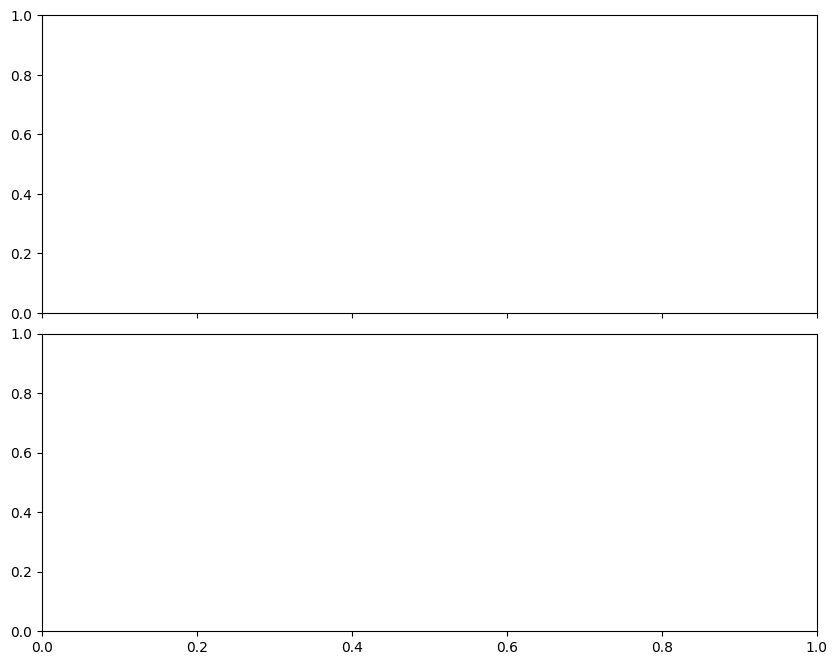

In [12]:
#idx = 2187 #1437
idx_0 = 2961
#idx_1 = np.random.choice(np.where((np.array(codes)=='00011') & (np.array(intervals) == '045_050'))[0])
#print(idx_1)

#idx_1 = 295, 254
idx_1 = 254

exp_freqs = np.array([2.9535, 3.5077, 4.0551, 4.5295, 4.8959]) * 10**9

freq_limits = np.array([2.9, 3.3, 3.7, 4.2, 4.7, 5.3]) * 10**9

fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)
fig.subplots_adjust(hspace=0.07)

axes[0].plot(freq.values[idx_start:]/10**9, X_abs[idx_0,idx_start:], label=np.array(codes)[idx_0])
axes[1].plot(freq.values[idx_start:]/10**9, X_abs[idx_1,idx_start:], label=np.array(codes)[idx_1])

for vline in freq_limits[1:-1]:
    axes[0].axvline(vline/10**9, color='black')
    axes[1].axvline(vline/10**9, color='black')

axes[0].set_xlim([2.9, 5.3])
axes[1].set_xlim([2.9, 5.3])

axes[1].set_xlabel('Frequency (GHz)')
axes[0].set_ylabel('Amplitude')
axes[1].set_ylabel('Amplitude')

#axes[0].set_title('Measurement at ' + str(intervals[idx_0]))
axes[0].legend()
axes[1].legend()

for ax in axes:
    set_axis(ax=ax, fontsize=14, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitude', tick_size=14)
    #set_axis(ax, fontsize=12, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitud (V)')

axes[0].set_xlabel('')
axes[0].text(2.6, 0.00123, 'a)', fontsize=12, fontweight='bold')
axes[1].text(2.6, 0.00083, 'b)', fontsize=12, fontweight='bold')

#adding rectangle
rectangle = rect((2.95,0.0), width=0.1, height=0.00084, fill=False,
                 edgecolor='red', linewidth=3, linestyle='--', facecolor='none')
axes[1].add_patch(rectangle)

fig.savefig('real_measurements.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('real_measurements.svg', dpi=300, bbox_inches='tight', transparent=True)

## Synthetic Noise and freq

In [13]:
X_synth, y_synth, freq_synth, _ = synthetic_tag_meas.generate_set(tags_list = ['01101'], meas_per_tag = 1,
                                                              freq_limits = freq_limits,
                                                              Q1=90, Q2=100, delta=50*10**6,
                                                              alpha1=0, alpha2=0, #setting alphas to zeros (no noise)
                                                              worN=freq.values[idx_start:], step_noise=1)
X_synth_abs = np.abs(X_synth)
codes_synth = [''.join(str(num) for num in row) for row in y_synth]

NameError: name 'freq' is not defined

In [14]:
# Radom synthetic signal from X_synth
idx = random.randint(0, X_synth_abs.shape[0]-1)
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(freq_synth/10**9, X_synth_abs.ravel())
ax.set_title(codes_synth)

for vline in freq_limits[1:-1]:
   ax.axvline(vline/10**9, color='black')

ax.set_xlim([2.9, 5.3])
fig.savefig('synthetic_signal.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('synthetic_signal.svg', dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'X_synth_abs' is not defined

In [ ]:
path = './raw_data/continuous_acquisitions/tag_00011_020_025_3'
os.chdir(path)
empty_file = ['empty_S21.sav']
X_empty, sources_empty = bit_wise_data_prep.read_list_of_empty_sav_files(empty_file)

In [72]:
X_empty_abs = abs(X_empty[0,:,0] + 1j*X_empty[0,:,1])

In [73]:
ar_model = AutoReg(X_empty_abs[idx_start:],
                  lags=500)
ar_model_fitted = ar_model.fit()

500


ValueError: x and y must have same first dimension, but have shapes (1201,) and (1251,)

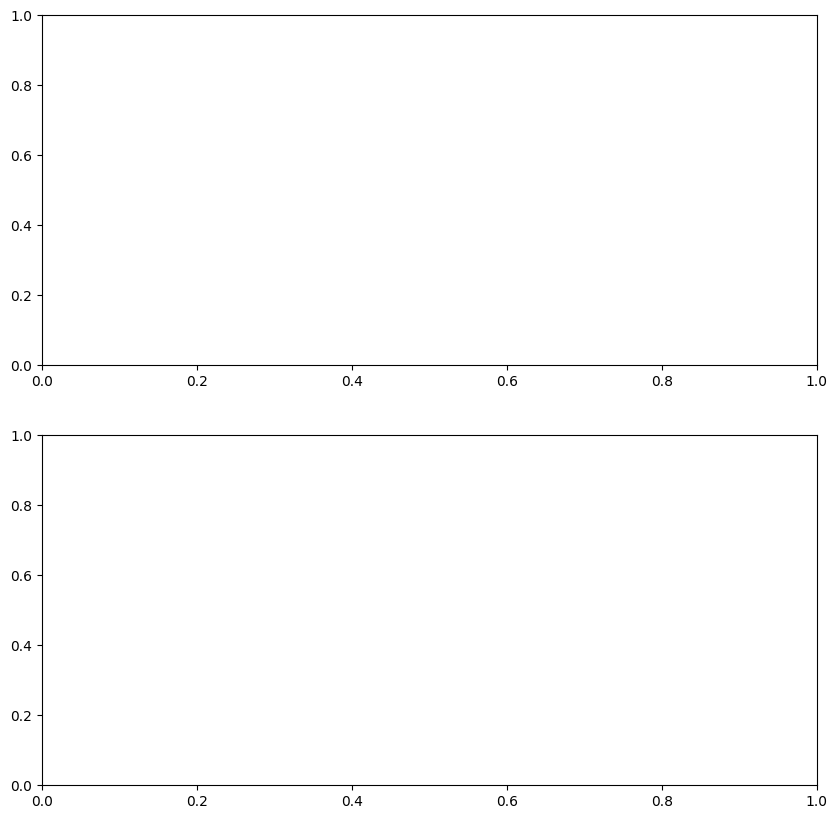

In [74]:
# noise generation example
n_samples = 1201

#random param to control starting point : from lags to 4000
start=random.randint(500, 650)
start=500
print(start)
noise = ar_model_fitted.predict(start=start, end=start+n_samples-1, dynamic=False)

_, axes = plt.subplots(2, 1, figsize=(10,10))

axes[0].plot(freq[idx_start:], X_empty_abs[idx_start:])
axes[0].set_title('Empty measurement')

axes[1].plot(freq[idx_start:], noise)
axes[1].set_title('Synthetic noise')

In [15]:
a = 0.2
delta = 1
normalized_noise = a + ((noise - min(noise))/(max(noise)-min(noise)))*delta

NameError: name 'noise' is not defined

In [16]:
X_synth_abs_noisy = X_synth_abs.ravel() + normalized_noise
X_min = min(X_synth_abs_noisy)
X_max = max(X_synth_abs_noisy)
X_synth_abs_noisy_norm =  (X_synth_abs_noisy - X_min) /(X_max - X_min)

NameError: name 'X_synth_abs' is not defined

In [17]:
idx_1 = np.where((np.array(codes) == '01101') & (np.array(intervals) == '020_025'))[0]
idx = np.random.choice(idx_1)
print(idx)

X_min = min(X_abs[idx, idx_start:])
X_max = max(X_abs[idx, idx_start:])
X_abs_norm =  (X_abs[idx, idx_start:] - X_min) /(X_max - X_min)

#fig, axes = plt.subplots(2, 1, figsize=(10,8))

axes[0].plot(freq_synth/10**9, X_abs_norm)
axes[1].plot(freq_synth/10**9, X_synth_abs_noisy_norm)
#axes[1].set_title(codes_synth)#

for vline in freq_limits[1:-1]:
   axes[0].axvline(vline/10**9, color='black')
   axes[1].axvline(vline/10**9, color='black')

axes[0].set_xlim([2.9, 5.3])
axes[1].set_xlim([2.9, 5.3])



fig.savefig('real_vs_synthetic_signal.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('real_vs_synthetic_signal.svg', dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'codes' is not defined

# Save Data

In [ ]:
#Saving data

data = {
   'X_real_norm' : X_abs_norm,
   'X_synth_noisy_norm' : X_synth_abs_noisy_norm,
   'X_synth_clean' : X_synth_abs.ravel(),
   'freq_synth' : freq_synth,
   'Empty' : X_empty_abs[idx_start:],
   'Synth_noise' : noise,
   'code' : codes_synth[0]
}
os.chdir(init_dir)

with open('/data/single_synth_data.pkl', 'wb') as file:
   pickle.dump(data, file)

# Load synthetic data/Analysis

In [11]:
with open('./data/single_synth_data.pkl', 'rb') as file:
    data = pickle.load(file)

In [12]:
data.keys()

dict_keys(['X_real_norm', 'X_synth_noisy_norm', 'X_synth_clean', 'freq_synth', 'Empty', 'Synth_noise', 'code'])

In [13]:
X_synth_clean = data['X_synth_clean']
codes_synth = data['code']
freq_synth = data['freq_synth']

NameError: name 'freq_limits' is not defined

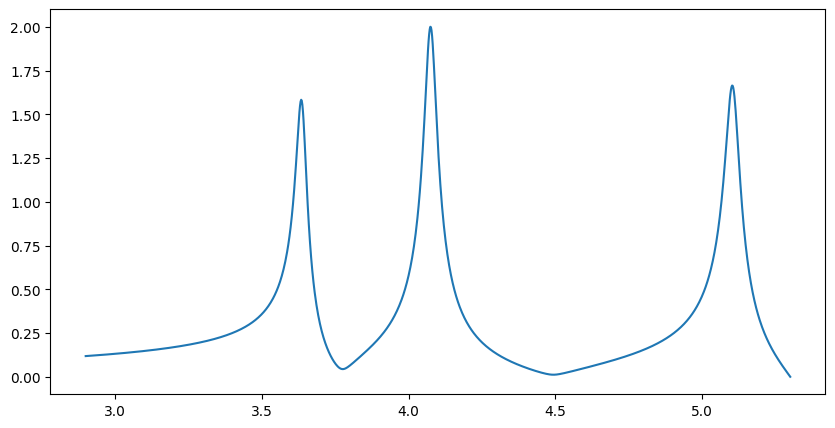

In [14]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(freq_synth/10**9, X_synth_clean.ravel(), label=codes_synth)

for vline in freq_limits[1:-1]:
    ax.axvline(vline/10**9, color='black')

set_axis(ax, fontsize=12, fontweight='bold')

ax.set_xlim([2.9, 5.3])
fig.savefig('synthetic_signal.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('synthetic_signal.svg', dpi=300, bbox_inches='tight', transparent=True)

In [15]:
X_empty = data['Empty']
noise = data['Synth_noise']

NameError: name 'freq' is not defined

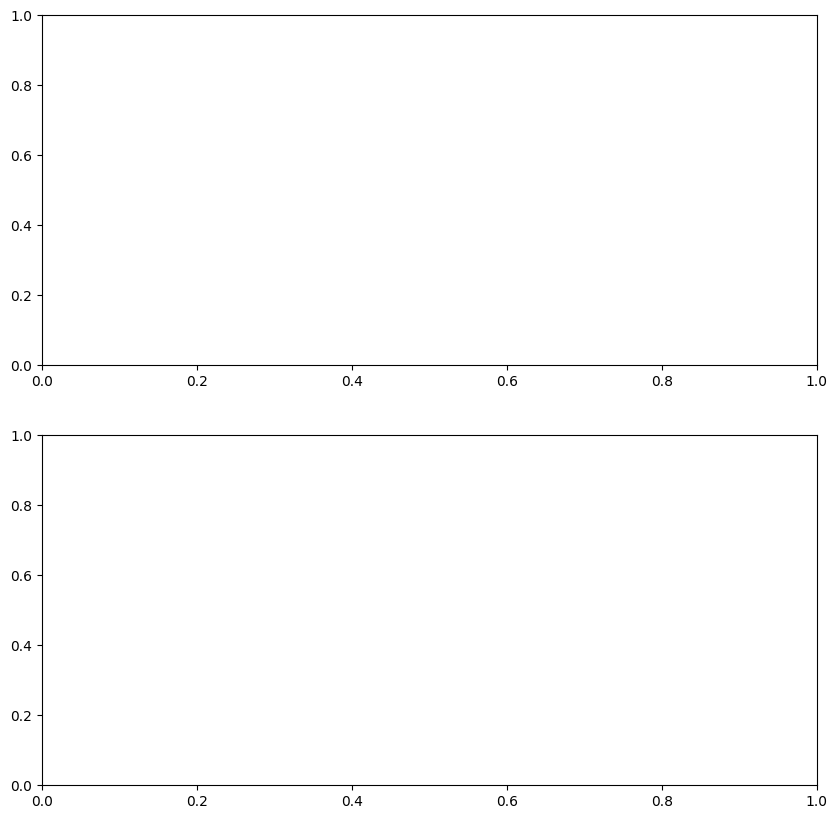

In [16]:
_, axes = plt.subplots(2, 1, figsize=(10,10))

axes[0].plot(freq.values[idx_start:], X_empty, label='Empty measurement')

axes[1].plot(freq.values[idx_start:], noise, label='Synthetic noise')

In [17]:
X_abs_norm = data['X_real_norm']
X_synth_abs_noisy_norm = data['X_synth_noisy_norm']

NameError: name 'freq_limits' is not defined

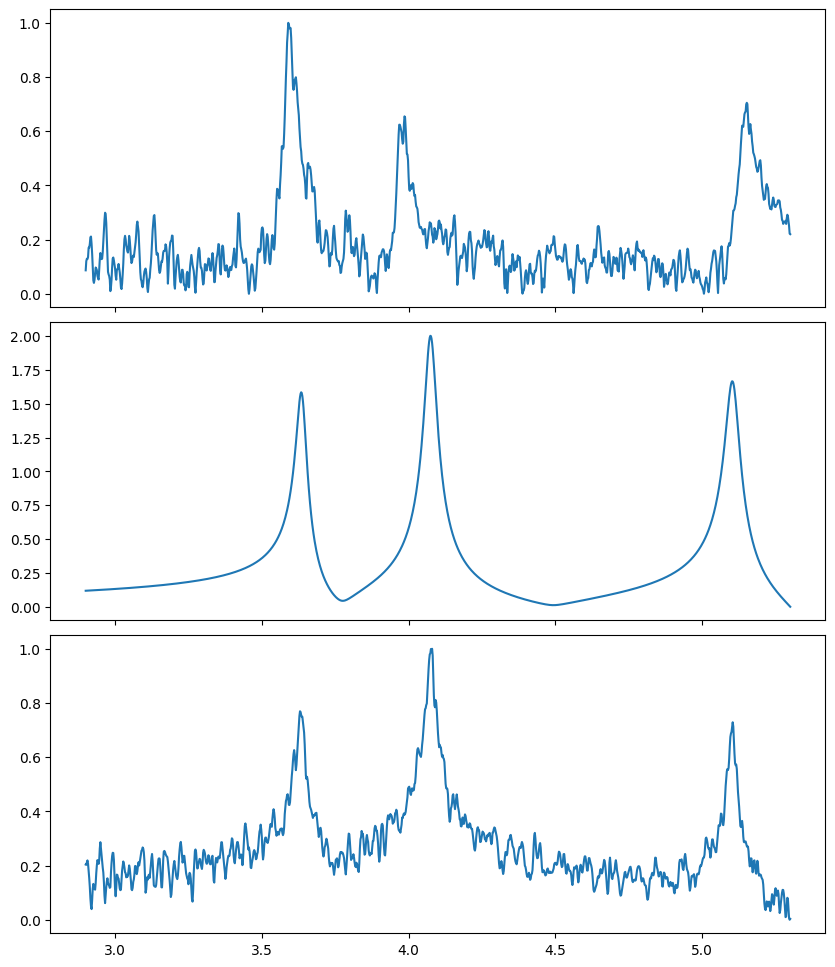

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(10,12), sharex=True)
fig.subplots_adjust(hspace=0.05)

axes[0].plot(freq_synth/10**9, X_abs_norm, label='Real measurement')
axes[1].plot(freq_synth/10**9, X_synth_clean.ravel(), label='Ideal signal')
axes[2].plot(freq_synth/10**9, X_synth_abs_noisy_norm, label='Final synthetic signal')
#axes[1].set_title(codes_synth)

for vline in freq_limits[1:-1]:
    axes[0].axvline(vline/10**9, color='black')
    axes[1].axvline(vline/10**9, color='black')
    axes[2].axvline(vline/10**9, color='black')

axes[0].set_xlim([2.9, 5.3])
axes[1].set_xlim([2.9, 5.3])
axes[2].set_xlim([2.9, 5.3])

axes[0].text(2.7, 1, 'a)', fontsize=12, fontweight='bold')
axes[1].text(2.7, 2, 'b)', fontsize=12, fontweight='bold')
axes[2].text(2.7, 1, 'c)', fontsize=12, fontweight='bold')

for ax in axes:
    set_axis(ax=ax, fontsize=14, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitude', tick_size=14)
    #set_axis(ax, fontsize=12, fontweight='bold', legend=False)

axes[0].set_xlabel('')
axes[1].set_xlabel('')

fig.savefig('real_vs_synthetic_signal.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('real_vs_synthetic_signal.svg', dpi=300, bbox_inches='tight', transparent=True)

NameError: name 'freq_limits' is not defined

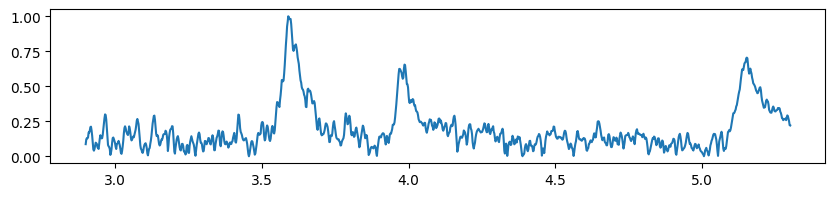

In [19]:
fig, axes = plt.subplots(figsize=(10,2))

axes.plot(freq_synth/10**9, X_abs_norm)
for vline in freq_limits[:]:
    axes.axvline(vline/10**9, color='black')

axes.axis('off')

# Continue from here Loading all data

In [20]:
path = './data/'
with open(path + 'data_bit_wise_training_final.pkl', 'rb') as file:
    data_train = pickle.load(file)

with open(path + 'data_bit_wise_synth_final.pkl', 'rb') as file:
    data_synth = pickle.load(file)

#with open('data_bit_wise_testing_final.pkl', 'rb') as file:
#    data_test = pickle.load(file)

with open(path + 'data_bit_wise_testing_final_v2.pkl', 'rb') as file:
    data_test = pickle.load(file)

with open(path + 'data_bit_wise_synth_white_noise.pkl', 'rb') as file:
    data_synth_white = pickle.load(file)

In [21]:
data_train.keys()

dict_keys(['X', 'y', 'codes', 'intervals', 'freq'])

In [22]:
X = data_train['X']
y = data_train['y']
codes = np.array(data_train['codes'])
intervals = data_train['intervals']
freq = data_train['freq']

In [23]:
idx_040_01101 = np.where((codes == '01101') & np.isin(intervals, ['040_045', '045_050']))[0]
idx_030_01101 = np.where((codes == '01101') & np.isin(intervals, ['030_035', '035_040']))[0]

In [24]:
min_max_norm(X[idx_030_01101[0]].T)

array([[0.12328083, 0.10115619, 0.10856137, ..., 0.26560662, 0.23306188,
        0.2002227 ]])

NameError: name 'freq_limits' is not defined

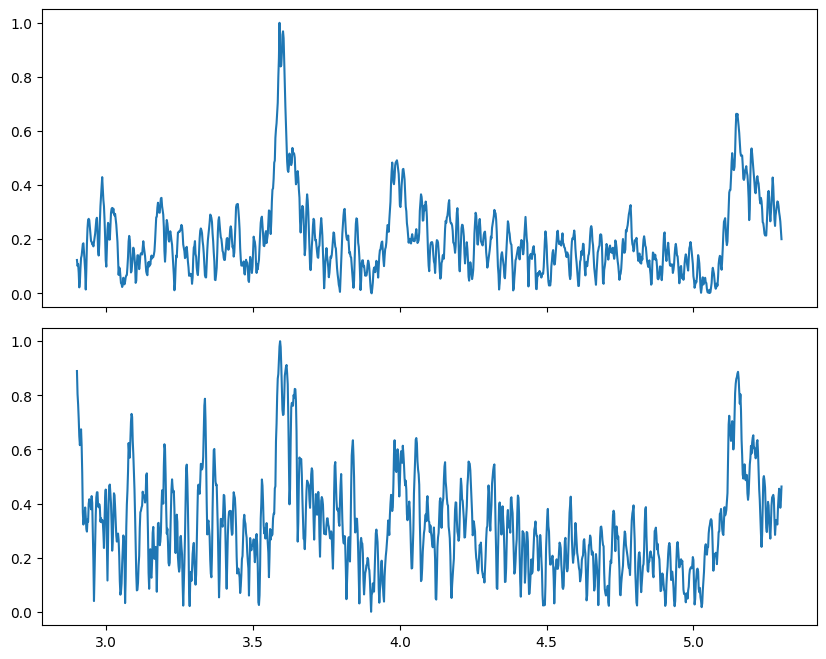

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)
fig.subplots_adjust(hspace=0.07)

#axes[0].plot(freq.values[idx_start:]/10**9, X_abs_norm[idx_0,idx_start:], label='030_040 cm')
#axes[1].plot(freq.values[idx_start:]/10**9, X_abs_norm[idx_1,idx_start:], label='040_050 cm')

axes[0].plot(freq.values/10**9, min_max_norm(X[idx_030_01101[0]].T).ravel(), label='030_040 cm')
axes[1].plot(freq.values/10**9, min_max_norm(X[idx_040_01101[0]].T).ravel(), label='040_050 cm')

for vline in freq_limits[1:-1]:
    axes[0].axvline(vline/10**9, color='black')
    axes[1].axvline(vline/10**9, color='black')

axes[0].set_xlim([2.9, 5.3])
axes[1].set_xlim([2.9, 5.3])

axes[1].set_xlabel('Frequency (GHz)')
axes[0].set_ylabel('Amplitude')
axes[1].set_ylabel('Amplitude')

#axes[0].set_title('Measurement at ' + str(intervals[idx_0]))
axes[0].legend()
axes[1].legend()

for ax in axes:
    set_axis(ax=ax, fontsize=14, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitude', tick_size=14)
    #set_axis(ax, fontsize=12, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitud (V)')

axes[0].set_xlabel('')
axes[0].text(2.7, 1, 'a)', fontsize=12, fontweight='bold')
axes[1].text(2.7, 1, 'b)', fontsize=12, fontweight='bold')

fig.savefig('meas_30_40.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('meas_30_40.svg', dpi=300, bbox_inches='tight', transparent=True)

In [26]:
X_synth = data_synth['X']
y_synth = data_synth['y']
codes_synth = data_synth['codes']
#freq_synth = data_train_synth['freq']

In [27]:
X_synth_white = data_synth_white['X']
y_synth_white = data_synth_white['y']
codes_synth_white = data_synth_white['codes']

In [28]:
X_test = data_test['X']
y_test = data_test['y']
codes_test = np.array(data_test['codes'])
intervals_test = data_test['intervals']
#freq_test = data_test['freq']

In [29]:
idx_020 = np.where(np.isin(intervals, ['020_025', '025_030']))[0]
idx_030 = np.where(np.isin(intervals, ['030_035', '035_030']))[0]
idx_040 = np.where(np.isin(intervals, ['040_045', '045_050']))[0]

In [30]:
idx_020_test = np.where(np.isin(intervals_test, ['020_025', '025_030']))[0]
idx_030_test = np.where(np.isin(intervals_test, ['030_035', '035_030']))[0]
idx_040_test = np.where(np.isin(intervals_test, ['040_045', '045_050']))[0]

In [31]:
np.isin(['intervals'], data_synth.keys())

array([False])

## Error right here

In [39]:
#Loading models
#The same model will be fit again in specific intervals.
path = './models/'
model_abs = tf.keras.models.load_model(path + 'final_model_abs.keras')
model_abs_20 = tf.keras.models.load_model(path + 'final_model_abs.keras')
model_abs_30 = tf.keras.models.load_model(path + 'final_model_abs.keras')
model_abs_40 = tf.keras.models.load_model(path + 'final_model_abs.keras')

model_synth = tf.keras.models.load_model(path + 'final_model_synth.keras')

AttributeError: 'SGD' object has no attribute 'build'

In [33]:
X_20, X_30, X_40 = X[idx_020], X[idx_030], X[idx_040]
y_20, y_30, y_40 = y[idx_020], y[idx_030], y[idx_040]
codes_20, codes_30, codes_40 = codes[idx_020], codes[idx_030], codes[idx_040]

In [34]:
X_synth_train, X_synth_valid, y_synth_train, y_synth_valid = train_test_split(
    X_synth, y_synth,
    test_size=0.1,
    random_state=123
)

In [35]:
X_synth_white_train, X_synth_white_valid, y_synth_white_train, y_synth_white_valid = train_test_split(
    X_synth_white, y_synth_white,
    test_size=0.1,
    random_state=123
)

In [36]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.1,
    random_state=123
)

In [37]:
X_train_20, X_valid_20, y_train_20, y_valid_20 = train_test_split(
    X_20, y_20,
    test_size=0.1,
    random_state=123
)

In [38]:
X_train_30, X_valid_30, y_train_30, y_valid_30 = train_test_split(
    X_30, y_30,
    test_size=0.1,
    random_state=123
)

In [39]:
X_train_40, X_valid_40, y_train_40, y_valid_40 = train_test_split(
    X_40, y_40,
    test_size=0.1,
    random_state=123
)

In [40]:
callback = EarlyStopping(monitor='loss', min_delta=0.001, patience=5)
code_length = y.shape[1]

In [41]:
# history = model_abs_20.fit(X_train_20, [y_train_20[:,i] for i in range(code_length)], epochs=500, batch_size=32,
#                    validation_data=(X_valid_20, [y_valid_20[:,i] for i in range(code_length)]), callbacks=[callback])

In [42]:
#history = model_abs_30.fit(X_train_30, [y_train_30[:,i] for i in range(code_length)], epochs=500, batch_size=32,
 #                   validation_data=(X_valid_30, [y_valid_30[:,i] for i in range(code_length)]), callbacks=[callback])

In [43]:
#history = model_abs_40.fit(X_train_40, [y_train_40[:,i] for i in range(code_length)], epochs=500, batch_size=32,
 #                   validation_data=(X_valid_40, [y_valid_40[:,i] for i in range(code_length)]), callbacks=[callback])

In [55]:
{'n_conv_layers': 5,
 'filters_conv0': 1,
 'kernel_size_conv0': 6,
 'stride_conv0': 1,
 'padding_conv0': 'valid',
 'activation_0': 'softplus',
 'filters_conv1': 4,
 'kernel_size_conv1': 13,
 'stride_conv1': 1,
 'padding_conv1': 'same',
 'activation_1': 'softplus',
 'filters_conv2': 5,
 'kernel_size_conv2': 8,
 'stride_conv2': 5,
 'padding_conv2': 'causal',
 'activation_2': 'softsign',
 'filters_conv3': 14,
 'kernel_size_conv3': 13,
 'stride_conv3': 4,
 'padding_conv3': 'same',
 'activation_3': 'softsign',
 'filters_conv4': 22,
 'kernel_size_conv4': 11,
 'stride_conv4': 3,
 'padding_conv4': 'valid',
 'activation_4': 'softplus',
 'pool_size_4': 3,
 'pool_stride_4': 1,
 'drop_rate_0': 0.18902994911778814,
 'drop_rate_1': 0.24438462995865295,
 'drop_rate_2': 0.2126736380034404,
 'drop_rate_3': 0.1398799536438109,
 'drop_rate_4': 0.49201699903870244,
 'learning_rate': 0.048184795169991926}

{'n_conv_layers': 5,
 'filters_conv0': 1,
 'kernel_size_conv0': 6,
 'stride_conv0': 1,
 'padding_conv0': 'valid',
 'activation_0': 'softplus',
 'filters_conv1': 4,
 'kernel_size_conv1': 13,
 'stride_conv1': 1,
 'padding_conv1': 'same',
 'activation_1': 'softplus',
 'filters_conv2': 5,
 'kernel_size_conv2': 8,
 'stride_conv2': 5,
 'padding_conv2': 'causal',
 'activation_2': 'softsign',
 'filters_conv3': 14,
 'kernel_size_conv3': 13,
 'stride_conv3': 4,
 'padding_conv3': 'same',
 'activation_3': 'softsign',
 'filters_conv4': 22,
 'kernel_size_conv4': 11,
 'stride_conv4': 3,
 'padding_conv4': 'valid',
 'activation_4': 'softplus',
 'pool_size_4': 3,
 'pool_stride_4': 1,
 'drop_rate_0': 0.18902994911778814,
 'drop_rate_1': 0.24438462995865295,
 'drop_rate_2': 0.2126736380034404,
 'drop_rate_3': 0.1398799536438109,
 'drop_rate_4': 0.49201699903870244,
 'learning_rate': 0.048184795169991926}

## model_abs

In [57]:
#Others
X_train_ = X_train
X_valid_ = X_valid

y_train_ = y_train
y_valid_ = y_valid
clear_session()
input_layer = Input(X_train.shape[1:])
#x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=[2.9e+09, 5.3e+09], normalize_index=0)(input_layer)
x = SegmentNormalizeLayer(freq=freq, freq_limits=freq_limits, normalize_index=0)(input_layer)
x = Conv1D(filters=1, kernel_size=6, strides=1, padding='valid', activation='softplus')(x)
x = Conv1D(filters=4, kernel_size=13, strides=1, padding='same', activation='softplus')(x)
x = Conv1D(filters=5, kernel_size=8, strides=5, padding='causal', activation='softsign')(x)
x = Conv1D(filters=14, kernel_size=13, strides=4, padding='same', activation='softsign')(x)
x = Conv1D(filters=22, kernel_size=11, strides=3, padding='valid', activation='softplus')(x)
x = MaxPool1D(pool_size=3, strides=1)(x)
x = Flatten()(x)

output_bloc = []
code_length = y_train.shape[1]
drop_rate = [0.4629312064295749, 0.13612447823526747, 0.057559989190043515, 0.14541316530039416, 0.1405031122563829]
#drop_rate = [0.18902994911778814, 0.24438462995865295, 0.2126736380034404,  0.1398799536438109, 0.49201699903870244]
for i in range(code_length):
    out = SelectiveDenseLayer(units=1, freq=freq, freq_limits=freq_limits[i:i+2])(x)
    out = Dropout(rate=drop_rate[i])(out)
    out = Activation('sigmoid')(out)
    output_bloc.append(out)

model_abs = Model(inputs=input_layer, outputs=output_bloc)

learning_rate = 0.06701661954069216
#learning_rate = 0.048184795169991926

model_abs.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])

history = model_abs.fit(X_train_, [y_train_[:,i] for i in range(code_length)], epochs=500, batch_size=32,
                   validation_data=(X_valid_, [y_valid_[:,i] for i in range(code_length)]), callbacks=[callback])

Epoch 1/500
81/81 [==============================] - 1s 7ms/step - loss: 3.4822 - activation_loss: 0.7060 - activation_1_loss: 0.6996 - activation_2_loss: 0.6736 - activation_3_loss: 0.7019 - activation_4_loss: 0.7011 - activation_accuracy: 0.4596 - activation_1_accuracy: 0.4920 - activation_2_accuracy: 0.5903 - activation_3_accuracy: 0.5029 - activation_4_accuracy: 0.5045 - val_loss: 3.5101 - val_activation_loss: 0.7236 - val_activation_1_loss: 0.6979 - val_activation_2_loss: 0.6689 - val_activation_3_loss: 0.7230 - val_activation_4_loss: 0.6966 - val_activation_accuracy: 0.4246 - val_activation_1_accuracy: 0.5193 - val_activation_2_accuracy: 0.6105 - val_activation_3_accuracy: 0.5123 - val_activation_4_accuracy: 0.5228
Epoch 2/500
81/81 [==============================] - 0s 5ms/step - loss: 3.4650 - activation_loss: 0.6975 - activation_1_loss: 0.6985 - activation_2_loss: 0.6699 - activation_3_loss: 0.6999 - activation_4_loss: 0.6992 - activation_accuracy: 0.4791 - activation_1_accura

## model_20

In [ ]:
model_abs_20 = tf.keras.models.clone_model(model_abs)
model_abs_20.set_weights(model_abs.get_weights())
model_abs_20.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])
model_abs_20.fit(X_train_20, [y_train_20[:,i] for i in range(code_length)], 
                  epochs=500, batch_size=32,
                  validation_data=(X_valid_20, [y_valid_20[:,i] for i in range(code_length)]), 
                  callbacks=[callback])

Epoch 1/500
27/27 [==============================] - 1s 20ms/step - loss: 0.7406 - activation_loss: 0.3409 - activation_1_loss: 0.1114 - activation_2_loss: 0.0582 - activation_3_loss: 0.1198 - activation_4_loss: 0.1103 - activation_accuracy: 0.7158 - activation_1_accuracy: 0.9251 - activation_2_accuracy: 0.9614 - activation_3_accuracy: 0.9146 - activation_4_accuracy: 0.9076 - val_loss: 0.0873 - val_activation_loss: 0.0327 - val_activation_1_loss: 0.0242 - val_activation_2_loss: 0.0114 - val_activation_3_loss: 0.0092 - val_activation_4_loss: 0.0098 - val_activation_accuracy: 0.9895 - val_activation_1_accuracy: 0.9895 - val_activation_2_accuracy: 1.0000 - val_activation_3_accuracy: 1.0000 - val_activation_4_accuracy: 1.0000
Epoch 2/500
27/27 [==============================] - 0s 4ms/step - loss: 0.7117 - activation_loss: 0.3358 - activation_1_loss: 0.1117 - activation_2_loss: 0.0624 - activation_3_loss: 0.1091 - activation_4_loss: 0.0927 - activation_accuracy: 0.7123 - activation_1_accur

## model_30

In [ ]:
# Fine-tune for 30-40cm
model_abs_30 = tf.keras.models.clone_model(model_abs)
model_abs_30.set_weights(model_abs.get_weights())
model_abs_30.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])
model_abs_30.fit(X_train_30, [y_train_30[:,i] for i in range(code_length)], 
                  epochs=500, batch_size=32,
                  validation_data=(X_valid_30, [y_valid_30[:,i] for i in range(code_length)]), 
                  callbacks=[callback])

Epoch 1/500
12/12 [==============================] - 1s 26ms/step - loss: 0.7013 - activation_loss: 0.3174 - activation_1_loss: 0.0886 - activation_2_loss: 0.0534 - activation_3_loss: 0.1242 - activation_4_loss: 0.1178 - activation_accuracy: 0.7639 - activation_1_accuracy: 0.9278 - activation_2_accuracy: 0.9583 - activation_3_accuracy: 0.9139 - activation_4_accuracy: 0.9278 - val_loss: 0.1838 - val_activation_loss: 0.0832 - val_activation_1_loss: 0.0175 - val_activation_2_loss: 0.0165 - val_activation_3_loss: 0.0556 - val_activation_4_loss: 0.0110 - val_activation_accuracy: 0.9750 - val_activation_1_accuracy: 1.0000 - val_activation_2_accuracy: 1.0000 - val_activation_3_accuracy: 0.9500 - val_activation_4_accuracy: 1.0000
Epoch 2/500
12/12 [==============================] - 0s 5ms/step - loss: 0.6532 - activation_loss: 0.3308 - activation_1_loss: 0.0910 - activation_2_loss: 0.0391 - activation_3_loss: 0.1101 - activation_4_loss: 0.0822 - activation_accuracy: 0.7722 - activation_1_accur

## Model_40

In [ ]:
# Fine-tune for 40-50cm
model_abs_40 = tf.keras.models.clone_model(model_abs)
model_abs_40.set_weights(model_abs.get_weights())
model_abs_40.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])
model_abs_40.fit(X_train_40, [y_train_40[:,i] for i in range(code_length)], 
                  epochs=500, batch_size=32,
                  validation_data=(X_valid_40, [y_valid_40[:,i] for i in range(code_length)]), 
                  callbacks=[callback])

Epoch 1/500
29/29 [==============================] - 1s 13ms/step - loss: 0.7740 - activation_loss: 0.3318 - activation_1_loss: 0.1497 - activation_2_loss: 0.0475 - activation_3_loss: 0.1290 - activation_4_loss: 0.1161 - activation_accuracy: 0.7289 - activation_1_accuracy: 0.9100 - activation_2_accuracy: 0.9700 - activation_3_accuracy: 0.9067 - activation_4_accuracy: 0.9244 - val_loss: 0.8657 - val_activation_loss: 0.1230 - val_activation_1_loss: 0.4655 - val_activation_2_loss: 0.0856 - val_activation_3_loss: 0.1329 - val_activation_4_loss: 0.0587 - val_activation_accuracy: 0.9900 - val_activation_1_accuracy: 0.7800 - val_activation_2_accuracy: 0.9600 - val_activation_3_accuracy: 0.9600 - val_activation_4_accuracy: 0.9900
Epoch 2/500
29/29 [==============================] - 0s 4ms/step - loss: 0.8074 - activation_loss: 0.3647 - activation_1_loss: 0.1696 - activation_2_loss: 0.0541 - activation_3_loss: 0.1064 - activation_4_loss: 0.1126 - activation_accuracy: 0.6956 - activation_1_accur

## Model Synth

In [63]:
#Training whit hybrid data
'''
X_train_ = np.concatenate((X_train, X_synth_train))
X_valid_ = np.concatenate((X_valid, X_synth_valid))

y_train_ = np.concatenate((y_train, y_synth_train))
y_valid_ = np.concatenate((y_valid, y_synth_valid))
'''

#Others
X_train_ = X_synth_train
X_valid_ = X_synth_valid

y_train_ = y_synth_train
y_valid_ = y_synth_valid
clear_session()
input_layer = Input(X_train.shape[1:])
#x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=[2.9e+09, 5.3e+09], normalize_index=0)(input_layer)
x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=freq_limits, normalize_index=0)(input_layer)
x = Conv1D(filters=1, kernel_size=6, strides=1, padding='valid', activation='softplus')(x)
x = Conv1D(filters=4, kernel_size=13, strides=1, padding='same', activation='softplus')(x)
x = Conv1D(filters=5, kernel_size=8, strides=5, padding='causal', activation='softsign')(x)
x = Conv1D(filters=14, kernel_size=13, strides=4, padding='same', activation='softsign')(x)
x = Conv1D(filters=22, kernel_size=11, strides=3, padding='valid', activation='softplus')(x)
x = MaxPool1D(pool_size=3, strides=1)(x)
x = Flatten()(x)

output_bloc = []
code_length = y_synth.shape[1]
#drop_rate = [0.4629312064295749, 0.13612447823526747, 0.057559989190043515, 0.14541316530039416, 0.1405031122563829]
drop_rate = [0.18902994911778814, 0.24438462995865295, 0.2126736380034404,  0.1398799536438109, 0.49201699903870244]
for i in range(code_length):
    out = SelectiveDenseLayer(units=1, freq=freq_synth, freq_limits=freq_limits[i:i+2])(x)
    out = Dropout(rate=drop_rate[i])(out)
    out = Activation('sigmoid')(out)
    output_bloc.append(out)

model_white = Model(inputs=input_layer, outputs=output_bloc)

learning_rate = 0.06701661954069216
#learning_rate = 0.048184795169991926

model_white.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])

history = model_white.fit(X_train_, [y_train_[:,i] for i in range(code_length)], epochs=500, batch_size=32,
                   validation_data=(X_valid_, [y_valid_[:,i] for i in range(code_length)]), callbacks=[callback])

Epoch 1/500
141/141 [==============================] - 2s 6ms/step - loss: 3.4714 - activation_loss: 0.6818 - activation_1_loss: 0.6985 - activation_2_loss: 0.6836 - activation_3_loss: 0.6978 - activation_4_loss: 0.7098 - activation_accuracy: 0.5549 - activation_1_accuracy: 0.5007 - activation_2_accuracy: 0.5449 - activation_3_accuracy: 0.4942 - activation_4_accuracy: 0.4973 - val_loss: 3.4694 - val_activation_loss: 0.6713 - val_activation_1_loss: 0.6932 - val_activation_2_loss: 0.6955 - val_activation_3_loss: 0.6959 - val_activation_4_loss: 0.7135 - val_activation_accuracy: 0.6040 - val_activation_1_accuracy: 0.4860 - val_activation_2_accuracy: 0.5800 - val_activation_3_accuracy: 0.4780 - val_activation_4_accuracy: 0.4800
Epoch 2/500
141/141 [==============================] - 1s 5ms/step - loss: 3.4536 - activation_loss: 0.6820 - activation_1_loss: 0.6959 - activation_2_loss: 0.6798 - activation_3_loss: 0.6954 - activation_4_loss: 0.7005 - activation_accuracy: 0.5491 - activation_1_ac

## Model Hybrid

In [64]:
#Training whit hybrid data

X_train_ = np.concatenate((X_train, X_synth_train))
X_valid_ = np.concatenate((X_valid, X_synth_valid))

y_train_ = np.concatenate((y_train, y_synth_train))
y_valid_ = np.concatenate((y_valid, y_synth_valid))


clear_session()
input_layer = Input(X_train.shape[1:])
#x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=[2.9e+09, 5.3e+09], normalize_index=0)(input_layer)
x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=freq_limits, normalize_index=0)(input_layer)
x = Conv1D(filters=1, kernel_size=6, strides=1, padding='valid', activation='softplus')(x)
x = Conv1D(filters=4, kernel_size=13, strides=1, padding='same', activation='softplus')(x)
x = Conv1D(filters=5, kernel_size=8, strides=5, padding='causal', activation='softsign')(x)
x = Conv1D(filters=14, kernel_size=13, strides=4, padding='same', activation='softsign')(x)
x = Conv1D(filters=22, kernel_size=11, strides=3, padding='valid', activation='softplus')(x)
x = MaxPool1D(pool_size=3, strides=1)(x)
x = Flatten()(x)

output_bloc = []
code_length = y_synth.shape[1]
#drop_rate = [0.4629312064295749, 0.13612447823526747, 0.057559989190043515, 0.14541316530039416, 0.1405031122563829]
drop_rate = [0.18902994911778814, 0.24438462995865295, 0.2126736380034404,  0.1398799536438109, 0.49201699903870244]
for i in range(code_length):
    out = SelectiveDenseLayer(units=1, freq=freq_synth, freq_limits=freq_limits[i:i+2])(x)
    out = Dropout(rate=drop_rate[i])(out)
    out = Activation('sigmoid')(out)
    output_bloc.append(out)

model_hybrid = Model(inputs=input_layer, outputs=output_bloc)

#learning_rate = 0.06701661954069216
learning_rate = 0.048184795169991926

model_hybrid.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])

history = model_hybrid.fit(X_train_, [y_train_[:,i] for i in range(code_length)], epochs=500, batch_size=32,
                   validation_data=(X_valid_, [y_valid_[:,i] for i in range(code_length)]), callbacks=[callback])

Epoch 1/500
221/221 [==============================] - 2s 5ms/step - loss: 3.4638 - activation_loss: 0.6824 - activation_1_loss: 0.6974 - activation_2_loss: 0.6801 - activation_3_loss: 0.6973 - activation_4_loss: 0.7066 - activation_accuracy: 0.5567 - activation_1_accuracy: 0.5063 - activation_2_accuracy: 0.5564 - activation_3_accuracy: 0.5028 - activation_4_accuracy: 0.4944 - val_loss: 3.4596 - val_activation_loss: 0.6826 - val_activation_1_loss: 0.6942 - val_activation_2_loss: 0.6769 - val_activation_3_loss: 0.7053 - val_activation_4_loss: 0.7005 - val_activation_accuracy: 0.5936 - val_activation_1_accuracy: 0.4981 - val_activation_2_accuracy: 0.5911 - val_activation_3_accuracy: 0.4904 - val_activation_4_accuracy: 0.5045
Epoch 2/500
221/221 [==============================] - 1s 5ms/step - loss: 3.4506 - activation_loss: 0.6818 - activation_1_loss: 0.6960 - activation_2_loss: 0.6778 - activation_3_loss: 0.6963 - activation_4_loss: 0.6988 - activation_accuracy: 0.5577 - activation_1_ac

## model_white

In [ ]:
#Training whit hybrid data
'''
X_train_ = np.concatenate((X_train, X_synth_train))
X_valid_ = np.concatenate((X_valid, X_synth_valid))

y_train_ = np.concatenate((y_train, y_synth_train))
y_valid_ = np.concatenate((y_valid, y_synth_valid))
'''

#Others
X_train_ = X_synth_white_train
X_valid_ = X_synth_white_valid

y_train_ = y_synth_white_train
y_valid_ = y_synth_white_valid

clear_session()
input_layer = Input(X_train.shape[1:])
#x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=[2.9e+09, 5.3e+09], normalize_index=0)(input_layer)
x = SegmentNormalizeLayer(freq=freq_synth, freq_limits=freq_limits, normalize_index=0)(input_layer)
x = Conv1D(filters=1, kernel_size=6, strides=1, padding='valid', activation='softplus')(x)
x = Conv1D(filters=4, kernel_size=13, strides=1, padding='same', activation='softplus')(x)
x = Conv1D(filters=5, kernel_size=8, strides=5, padding='causal', activation='softsign')(x)
x = Conv1D(filters=14, kernel_size=13, strides=4, padding='same', activation='softsign')(x)
x = Conv1D(filters=22, kernel_size=11, strides=3, padding='valid', activation='softplus')(x)
x = MaxPool1D(pool_size=3, strides=1)(x)
x = Flatten()(x)

output_bloc = []
code_length = y_synth.shape[1]
#drop_rate = [0.4629312064295749, 0.13612447823526747, 0.057559989190043515, 0.14541316530039416, 0.1405031122563829]
drop_rate = [0.18902994911778814, 0.24438462995865295, 0.2126736380034404,  0.1398799536438109, 0.49201699903870244]
for i in range(code_length):
    out = SelectiveDenseLayer(units=1, freq=freq_synth, freq_limits=freq_limits[i:i+2])(x)
    out = Dropout(rate=drop_rate[i])(out)
    out = Activation('sigmoid')(out)
    output_bloc.append(out)

model_13 = Model(inputs=input_layer, outputs=output_bloc)

#learning_rate = 0.06701661954069216
learning_rate = 0.048184795169991926

model_13.compile(loss='binary_crossentropy', optimizer=SGD(learning_rate=learning_rate), metrics=['accuracy'])

history = model_13.fit(X_train_, [y_train_[:,i] for i in range(code_length)], epochs=500, batch_size=32,
                   validation_data=(X_valid_, [y_valid_[:,i] for i in range(code_length)]), callbacks=[callback])

## Save all models

In [ ]:
#saving models
# path = './models/'
# model_abs.save(path + 'final_model_abs.keras')
# model_abs_20.save(path + 'final_model_abs_20.keras')
# model_abs_30.save(path + 'final_model_abs_30.keras')
# model_abs_40.save(path + 'final_model_abs_40.keras')
# model_white.save(path + 'final_model_white.keras')
# model_hybrid.save(path + 'final_model_hybrid.keras')

In [61]:
model_abs = tf.keras.models.load_model('./models/final_model_abs.keras')
model_abs_20 = tf.keras.models.load_model('./models/final_model_abs_20.keras')
model_abs_30 = tf.keras.models.load_model('./models/final_model_abs_30.keras')
model_abs_40 = tf.keras.models.load_model('./models/final_model_abs_40.keras')

AttributeError: 'SGD' object has no attribute 'build'

In [ ]:
model_synth = tf.keras.models.load_model('./models/final_model_synth_final.keras')

In [ ]:
model_hybrid = tf.keras.models.load_model('./models/final_model_hybrid.keras')

In [ ]:
model_white = tf.keras.models.load_model('./models/final_model_white.keras')

In [66]:
model_white.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1201, 1)]            0         []                            
                                                                                                  
 segment_normalize_layer (S  (None, 1200, 1)              0         ['input_1[0][0]']             
 egmentNormalizeLayer)                                                                            
                                                                                                  
 conv1d (Conv1D)             (None, 1195, 1)              7         ['segment_normalize_layer[0][0
                                                                    ]']                           
                                                                                              

## Model Predictions

In [ ]:
'''
model = model_abs

X_1 = X_train
y_1 = y_train

alpha_0 = 280
alpha_1 = 180

proba_train = model.predict(X_1, verbose=False)
proba_train = np.array(proba_train).ravel()
bit_pred = (proba_train > 0.5).astype(int)

df = pd.DataFrame(
    {
        'Probabilities' : proba_train,
        'Labels_pred' : bit_pred,
        'Labels' : y_1.ravel(),
        'Accurate Prediction' : bit_pred == y_1.ravel()
    }
)

percentiles = df.groupby('Labels_pred')['Probabilities'].quantile([0.25, 0.75]).values
lower_bound_thr = percentiles[1] + alpha_0*(percentiles[1] - percentiles[0])
upper_bound_thr = percentiles[2] - alpha_1*(percentiles[3] - percentiles[2])

#lower_bound_thr = max(lower_bound_thr, 0.1)
#upper_bound_thr = min(upper_bound_thr, 0.85)
print(lower_bound_thr)
print(upper_bound_thr)
'''

In [ ]:
'''
thresholds = {
    '0' : lower_bound_thr,
    '1' : upper_bound_thr
}

fig = plt.figure(figsize=(10,6))
ax = sns.boxplot(x='Labels_pred', y='Probabilities',
                 hue='Accurate Prediction',
                 #orient='y',
                 data=df.iloc[np.where(df.Labels_pred == 0)])


xmin, xmax = plt.ylim()
yticks = ax.get_yticks()
width = 1 #the width between the ticks

for i, (label, thr) in enumerate(thresholds.items()):

    #box = ax.artists[i]
    #width = box.get_width()
    #x = box.get_x() + width / 2
    y = xticks[i]

    plt.vlines(thr, y - width / 2, y + width / 2, color='red', linestyle='--')
    #plt.hlines(percentile, x - width / 2, x + width / 2, linestyle='--', label=percentile)
    #xpos = list(percentiles.keys()).index(label)
    #ax.text(xpos, percentile, f' 10th P: {percentile:.2f}', color='black', va='bottom', ha='center')

#ax.legend()
#for i in range(len(yticks_names)):
 #   yticks_names[i] = yticks_names[i][4:]

#ax.set_xticklabels(xticks_names)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)

ax.set_ylabel('Bit value', fontsize=12, fontweight='bold')
ax.set_xlabel('Probabilities', fontsize=12, fontweight='bold')

fig.savefig('threshold_bit_wise.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('threshold_bit_wise.svg', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('threshold_bit_wise.png', dpi=300, bbox_inches='tight', transparent=True)
'''

In [ ]:
# Computational cost
start_time = time.perf_counter()  # High-resolution timer

predict_proba = model_abs.predict(X[0:1], verbose=0)
y_pred = np.argmax(predict_proba, axis=1)

end_time = time.perf_counter()

# Print execution time with more precision
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.10f} seconds")

In [67]:
model = model_abs
#model = model_abs_20
#model = model_abs_30
#model = model_abs_40
#model = model_synth
#model = model_hybrid

X_1 = X_train
#X_1 = X_train_20
#X_1 = X_train_30
#X_1 = X_train_40
#X_1 = X_synth
#X_1 = np.concatenate((X_synth, X_train))

alpha_0 = 40
alpha_1 = 60

#alpha_0 = 10
#alpha_1 = 30

#alpha_0 = 7
#alpha_1 = 10

#alpha_0 = 20
#alpha_1 = 65


proba_train = model.predict(X_1, verbose=False)
proba_train = np.array(proba_train).ravel()
bit_pred = (proba_train > 0.5).astype(int)

df = pd.DataFrame(
    {
        'Probas' : proba_train,
        'Labels' : bit_pred
    }
)

percentiles = df.groupby('Labels')['Probas'].quantile([0.25, 0.75]).values
lower_bound_thr = percentiles[1] + alpha_0*(percentiles[1] - percentiles[0])
upper_bound_thr = percentiles[2] - alpha_1*(percentiles[3] - percentiles[2])

#lower_bound_thr = max(lower_bound_thr, 0.1)
#upper_bound_thr = min(upper_bound_thr, 0.85)
print(lower_bound_thr)
print(upper_bound_thr)

1.2862645178101957
0.8445710241794586


In [ ]:
def correct_predictions(y_pred_proba, y_test):
    yt_unique = np.unique(y_test, axis=0)
    y_pred_bit = y_pred_proba.round().astype(int)

    yt_set = set(map(tuple, yt_unique)) # Converting arrays to sets of tuples for easy comparison
    valid_mask = np.array([tuple(row) in yt_set for row in y_pred_bit]) # Valid predictions

    # Finding indices of invalid rows
    invalid_indices = np.where(~valid_mask)[0]

    if len(invalid_indices) == 0:
        return y_pred_bit

    # Computing Hamming distances between wrong predictions and yt_unique
    h_distances = cdist(y_pred_bit[invalid_indices], yt_unique, metric='hamming')

    min_indices = [np.where(row == row.min())[0] for row in h_distances]

    # Nearest valid code
    nearest_indices = []

    for i in range(len(min_indices)):
        if len(min_indices[i]) == 1:
            #print(min_indices[i])
            nearest_indices.append(min_indices[i][0])
        else:
            P = y_pred_proba[invalid_indices][i]
            P_rounded = P.round().astype(int)
            #print(P_rounded)
            mismatches = yt_unique[min_indices[i]] != P_rounded # Where the nearest true labels bits are different to the predicted bits
            #print(mismatches)
            distance_sums = np.sum(np.abs(P - 0.5) * mismatches, axis=1) # Sum of the distance to 0.5 where there is a mismatch
            nearest_indices.append(min_indices[i][distance_sums.argmin()])
            #print(min_indices[i])
            #print(distance_sums)
            #print(min_indices[i][distance_sums.argmin()])

    corrected_y_pred = y_pred_bit.copy()
    corrected_y_pred[invalid_indices] = yt_unique[nearest_indices]

    return corrected_y_pred

In [ ]:
y_test[:10]

In [ ]:
y_pred[:10].round()

## Prediction Analysis

47/47 [==============================] - 0s 2ms/step


(<Axes: xlabel='Predicted label\n\nConserved good predictions ratio=1.0000\nConserved bad predictions ratio=1.0000\nConverved predictions ratio=1.0000\nAccuracy before filtering=0.8827\nAccuracy after filtering=0.8827', ylabel='True label'>,
 0.8826666666666667,
 1.0,
 1.0)

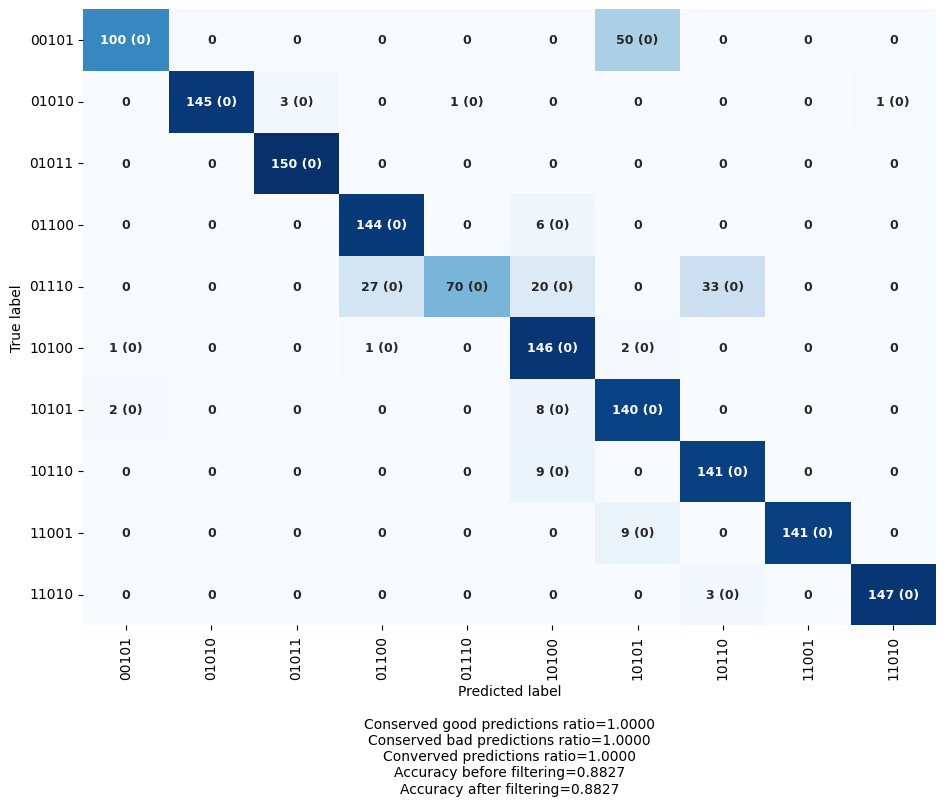

In [68]:
idx = np.where(np.isin(intervals_test,['020_030',
                                       '030_040',
                                       '040_050'
                                      ]))[0]
X_1 = X_test[idx]
y_1 = y_test[idx]

#X_1 = X_valid_40
#y_1 = y_valid_40

model = model_abs
#model = model_synth
#model = model_hybrid

df_pred, y_pred, y_test_cm, y_pred_cm = testing_utilities.testing_bit_wise(X_1, y_1, model,
                                                                           show_cm=False, correct_pred=True,
                                                                           figsize=(16,10))

y_test_cm = np.array(y_test_cm)
y_pred_cm = np.array(y_pred_cm)

le = LabelEncoder()
categories = np.unique(np.concatenate((y_pred_cm,y_test_cm))) #change this. categories should includ all the availabes in y_pred and y
le.fit(categories)

cm = confusion_matrix(y_test_cm, y_pred_cm)

#Test whether all probabilitie are lower or greater than defined thresholds
confident_pred_idx = np.all((y_pred < lower_bound_thr) | (y_pred > upper_bound_thr), axis=1)

cm2 = np.zeros((len(categories), len(categories)))

for cont, res in zip(le.transform(y_test_cm[confident_pred_idx]), le.transform(y_pred_cm[confident_pred_idx])):
    cm2[cont, res] += 1

fig, ax = plt.subplots(figsize=(11,8))

yticklabels=categories
#dropping void row in the confusions matrix
'''
zero_rows = np.all(cm == 0, axis=1)
cm = cm[~zero_rows]
cm2 = cm2[~zero_rows]
yticklabels=categories[~zero_rows]
'''

make_confusion_matrix(cm, cm2,
                      categories=categories,
                      yticklabels=yticklabels,
                      xticklabels=categories,
                      figsize=(11, 8),
                            percent=False,
                            sum_stats=True,
                            x_rotation=90,
                            cbar=False, ax=ax)

#ax.set_xlabel('Predicted label')
#set_axis(ax, fontsize=10, fontweight='bold', legend=False)

#fig.savefig('confusion_matrix_real_new.pdf', dpi=300, bbox_inches='tight', transparent=True)
#fig.savefig('confusion_matrix_real_new.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
#data_max = dict()

In [ ]:
#data_max['y_true_all'] = y_1
#data_max['y_pred_all'] = y_pred.round().astype(int)
#data_max['confident_pred_idx_all'] = confident_pred_idx
#data_max['corrected_y_pred_all'] = correct_predictions(y_pred, y_test[idx])

In [ ]:
#with open('predictions_models_hybrid.pkl', 'wb') as file:
#    pickle.dump(data_max, file)

In [ ]:
corrected_y_pred = correct_predictions(y_pred[idx], y_test[idx])

1171


(2.9, 5.3)

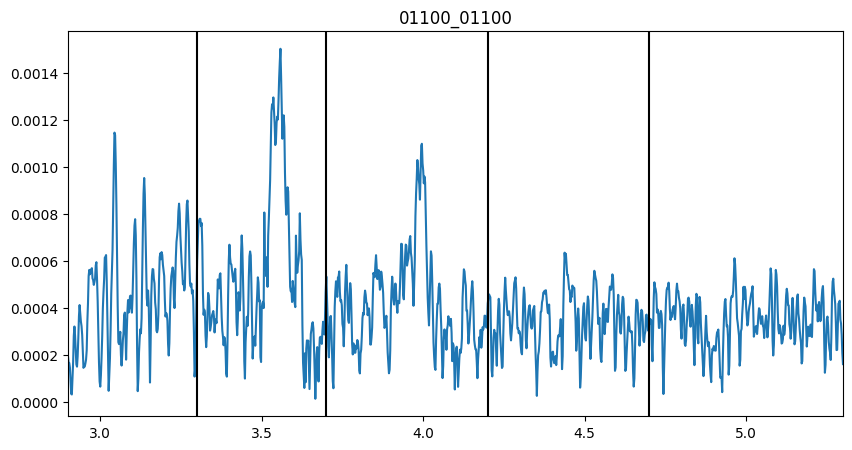

In [69]:
#False predictions
idx = np.random.choice(np.where(y_pred_cm[confident_pred_idx] == y_test_cm[confident_pred_idx])[0])
print(idx)

fig, axes = plt.subplots(figsize=(10,5))

axes.plot(freq_synth/10**9, X_1[confident_pred_idx][idx])
axes.set_title(''.join(str(a) for a in y_1[confident_pred_idx][idx]) + '_' + y_pred_cm[confident_pred_idx][idx])

for vline in freq_limits[1:-1]:
    axes.axvline(vline/10**9, color='black')

axes.set_xlim([2.9, 5.3])

#fig.savefig('focus_on_well_classified.pdf', dpi=300, bbox_inches='tight', transparent=True)
#fig.savefig('focus_on_well_classified.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
axes[a, b].get_ylim()

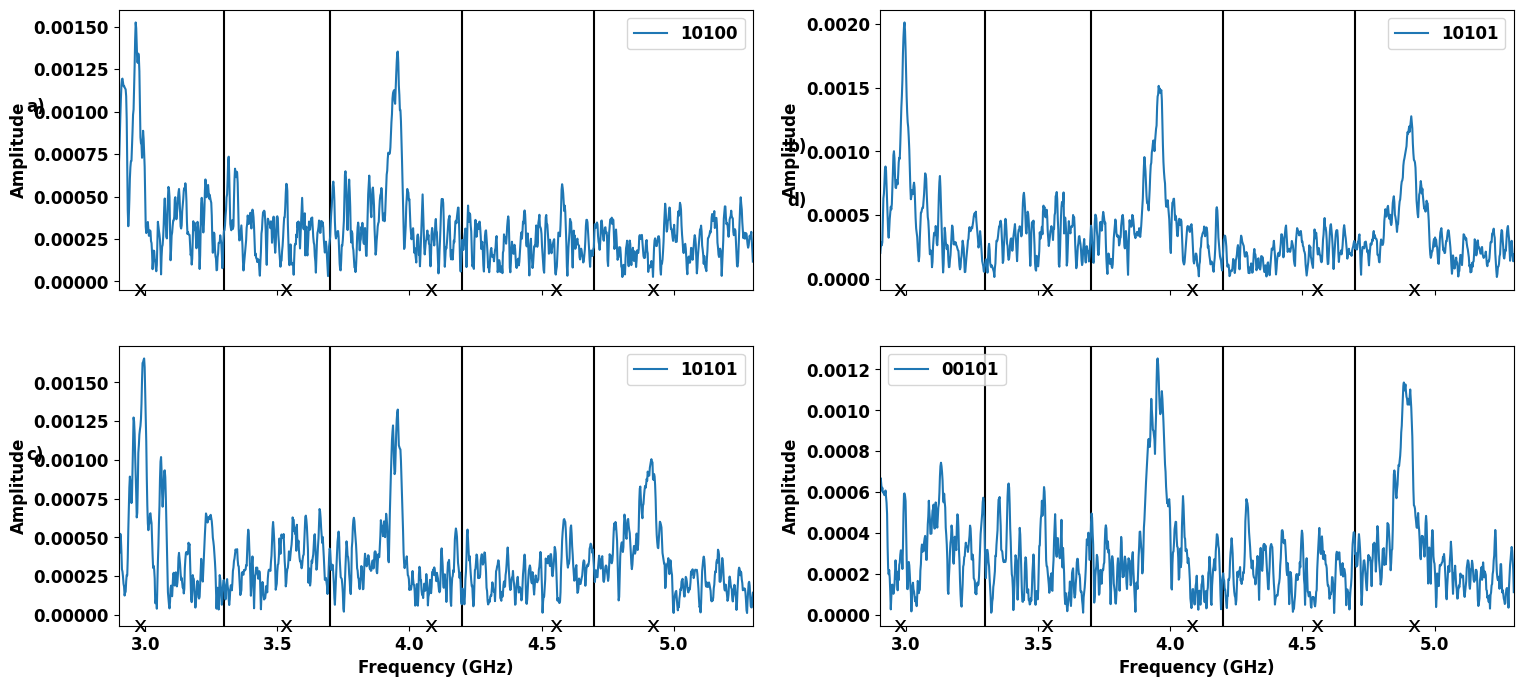

In [70]:
idx = [784, 802, 840, 526,
       #500
      ]
labels = [''.join(str(a) for a in y_1[confident_pred_idx][i]) for i in idx]

exp_freqs = np.array([2.9535, 3.5077, 4.0551, 4.5295, 4.8959]) * 10**9

freq_limits = np.array([2.9, 3.3, 3.7, 4.2, 4.7, 5.3]) * 10**9

fig, axes = plt.subplots(2, 2, figsize=(18,8), sharex=True)

for i in range(len(idx)):
    a = i // 2
    b = i % 2
    for vline in freq_limits[1:-1]:
        axes[a, b].axvline(vline/10**9, color='black')

    axes[a, b].plot(freq.to_numpy()/10**9, X_1[confident_pred_idx][idx[i]],
            label=labels[i]
           )
    axes[a, b].set_xlim([2.9, 5.3])
    axes[a, b].legend()

    #min_dis_y = axes[a, b].get_ylim()[0] #lowest value displayed on y-axis
    for pt in exp_freqs/10**9:
        axes[a, b].text(pt, axes[a, b].get_ylim()[0] - axes[a, b].get_ylim()[1]/45, 'x', fontsize=16)

    set_axis(ax=axes[a, b], fontsize=12, fontweight='bold', ylabel='Amplitude', xlabel='')


axes[1,0].set_xlabel('Frequency (GHz)')
axes[1,1].set_xlabel('Frequency (GHz)')

axes[0,0].text(2.55, 0.001, 'a)', fontsize=12, fontweight='bold')
axes[0,1].text(2.55, 0.001, 'b)', fontsize=12, fontweight='bold')
axes[1,0].text(2.55, 0.001, 'c)', fontsize=12, fontweight='bold')
axes[1,1].text(2.55, 0.002, 'd)', fontsize=12, fontweight='bold')
'''

ax.set_xlim([2.9, 5.3])
#ax.set_ylim([0, 0.013])

#ax.set_title('Some references used to define the bounders')
ax.legend()

set_axis(ax=ax, fontsize=12, fontweight='bold')
'''

fig.savefig('extrem_good_predictions.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('extrem_good_predictions.svg', dpi=300, bbox_inches='tight', transparent=True)

In [71]:
freq_limits

array([2.9e+09, 3.3e+09, 3.7e+09, 4.2e+09, 4.7e+09, 5.3e+09])

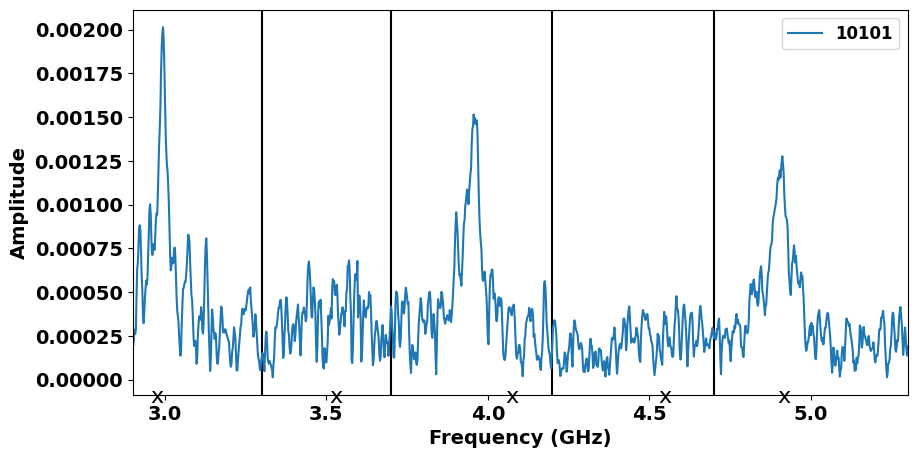

In [72]:
fig, ax = plt.subplots(figsize=(10,5), sharex=True)
pos = 1
idx_ = idx[pos]
label_ = labels[pos]

for vline in freq_limits[1:-1]:
    ax.axvline(vline/10**9, color='black')

ax.plot(freq.to_numpy()/10**9, X_1[confident_pred_idx][idx_],
        label=label_
       )
ax.set_xlim([2.9, 5.3])
ax.legend()

#min_dis_y = axes[a, b].get_ylim()[0] #lowest value displayed on y-axis
for pt in exp_freqs/10**9:
    ax.text(pt, ax.get_ylim()[0] - ax.get_ylim()[1]/45, 'x', fontsize=16)

set_axis(ax=ax, fontsize=14, fontweight='bold', ylabel='Amplitude', xlabel='Frequency (GHz)', tick_size=14)
'''

ax.set_xlim([2.9, 5.3])
#ax.set_ylim([0, 0.013])
ax.set_xlabel('Frequency (GHz)')
ax.set_ylabel('Amplitude')
#ax.set_title('Some references used to define the bounders')
ax.legend()

set_axis(ax=ax, fontsize=12, fontweight='bold')
'''

fig.savefig('extrem_good_prediction_one.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('extrem_good_prediction_one.svg', dpi=300, bbox_inches='tight', transparent=True)

In [73]:
np.isin(np.array(intervals_test),['040_050']).sum()

500

In [74]:
idx_1 = np.random.choice(np.where((np.array(codes_test)=='01101') & (np.isin(np.array(intervals_test),['040_050'])))[0])

ValueError: 'a' cannot be empty unless no samples are taken

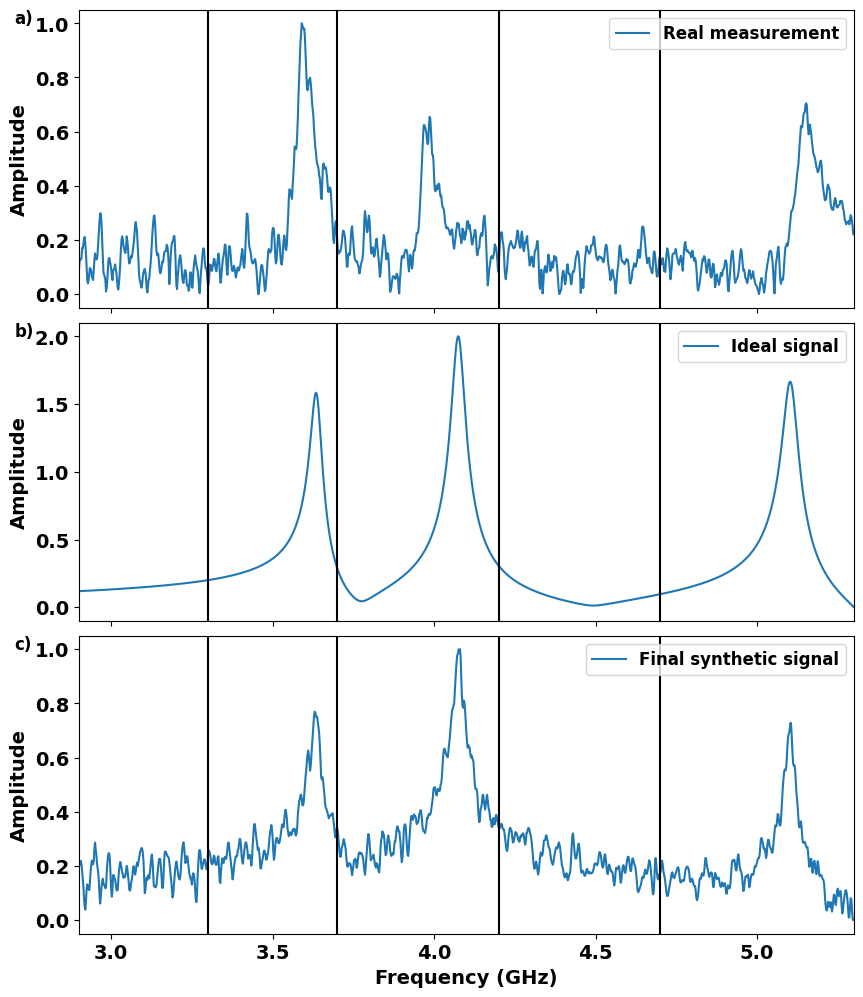

In [75]:
fig, axes = plt.subplots(3, 1, figsize=(10,12), sharex=True)
fig.subplots_adjust(hspace=0.05)

axes[0].plot(freq_synth/10**9, X_abs_norm, label='Real measurement')
axes[1].plot(freq_synth/10**9, X_synth_clean.ravel(), label='Ideal signal')
axes[2].plot(freq_synth/10**9, X_synth_abs_noisy_norm, label='Final synthetic signal')
#axes[1].set_title(codes_synth)

for vline in freq_limits[1:-1]:
    axes[0].axvline(vline/10**9, color='black')
    axes[1].axvline(vline/10**9, color='black')
    axes[2].axvline(vline/10**9, color='black')

axes[0].set_xlim([2.9, 5.3])
axes[1].set_xlim([2.9, 5.3])
axes[2].set_xlim([2.9, 5.3])

axes[0].text(2.7, 1, 'a)', fontsize=12, fontweight='bold')
axes[1].text(2.7, 2, 'b)', fontsize=12, fontweight='bold')
axes[2].text(2.7, 1, 'c)', fontsize=12, fontweight='bold')

for ax in axes:
    set_axis(ax=ax, fontsize=14, fontweight='bold', xlabel='Frequency (GHz)', ylabel='Amplitude', tick_size=14)
    #set_axis(ax, fontsize=12, fontweight='bold', legend=False)

axes[0].set_xlabel('')
axes[1].set_xlabel('')

fig.savefig('real_vs_synthetic_signal.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('real_vs_synthetic_signal.svg', dpi=300, bbox_inches='tight', transparent=True)

In [76]:
model = model_synth

X_1 = X_synth

alpha_0 = 7
alpha_1 = 10

proba_train = model.predict(X_1, verbose=False)
proba_train = np.array(proba_train).ravel()
bit_pred = (proba_train > 0.5).astype(int)

df = pd.DataFrame(
    {
        'Probas' : proba_train,
        'Labels' : bit_pred
    }
)

percentiles = df.groupby('Labels')['Probas'].quantile([0.25, 0.75]).values
lower_bound_thr = percentiles[1] + alpha_0*(percentiles[1] - percentiles[0])
upper_bound_thr = percentiles[2] - alpha_1*(percentiles[3] - percentiles[2])

#lower_bound_thr = max(lower_bound_thr, 0.1)
#upper_bound_thr = min(upper_bound_thr, 0.85)
print(lower_bound_thr)
print(upper_bound_thr)

NameError: name 'model_synth' is not defined

16/16 [==============================] - 0s 2ms/step


(<Axes: xlabel='Predicted label\n\nConserved good predictions ratio=1.0000\nConserved bad predictions ratio=1.0000\nConverved predictions ratio=1.0000\nAccuracy before filtering=0.8440\nAccuracy after filtering=0.8440', ylabel='True label'>,
 0.844,
 1.0,
 1.0)

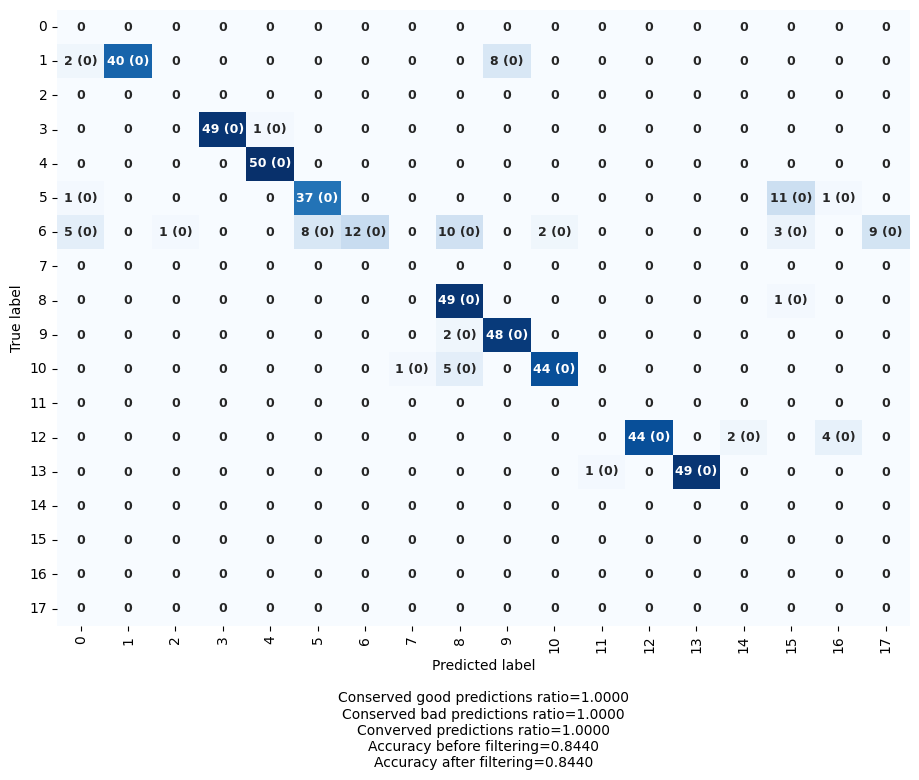

In [77]:
idx = np.where(np.isin(intervals_test,['020_030',
                                      #'030_040',
                                      #'040_050'
]))[0]

X_1 = X_test[idx]
y_1 = y_test[idx]

#X_1 = X_valid_30
#y_1 = y_valid_30

model = model_abs

df_pred, y_pred, y_test_cm, y_pred_cm = testing_utilities.testing_bit_wise(X_1, y_1, model,
                                                                           show_cm=False, figsize=(16,10))

y_test_cm = np.array(y_test_cm)
y_pred_cm = np.array(y_pred_cm)

le = LabelEncoder()
categories = np.unique(np.concatenate((y_pred_cm,y_test_cm))) #change this. categories should includ all the availabes in y_pred and y
le.fit(categories)

cm = confusion_matrix(y_test_cm, y_pred_cm)

#Test whether all probabilitie are lower or greater than defined thresholds
confident_pred_idx = np.all((y_pred < lower_bound_thr) | (y_pred > upper_bound_thr), axis=1)

cm2 = np.zeros((len(categories), len(categories)))

for cont, res in zip(le.transform(y_test_cm[confident_pred_idx]), le.transform(y_pred_cm[confident_pred_idx])):
    cm2[cont, res] += 1

fig, ax = plt.subplots(figsize=(11,8))

yticklabels=categories
#dropping void row in the confusions matrix
'''
zero_rows = np.all(cm == 0, axis=1)
cm = cm[~zero_rows]
cm2 = cm2[~zero_rows]
yticklabels=categories[~zero_rows]
'''

make_confusion_matrix(cm, cm2,
                      #categories=categories,
                      yticklabels=yticklabels,
                      xticklabels=categories,
                      figsize=(11, 8),
                            percent=False,
                            sum_stats=True,
                            x_rotation=90,
                            cbar=False, ax=ax)

#ax.set_xlabel('Predicted label')
#ax.set_xlabel('Predicted label')
#set_axis(ax, fontsize=10, fontweight='bold', legend=False)

#fig.savefig('confusion_matrix_real_zeros_rows_dropped.pdf', dpi=300, bbox_inches='tight', transparent=True)
#fig.savefig('confusion_matrix_real_zeros_rows_dropped.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
'''
idx_final = []

for code in np.unique(codes_test)[1:]:
    idx_all = np.where((y_test_cm==code))[0]
    idx_noConf_bad = np.where(~confident_pred_idx & (y_pred_cm != y_test_cm) & (y_test_cm==code))[0]

    idx_remain = np.array(list(set(idx_all) - set(idx_noConf_bad)))

    idx_noConf_bad_half = np.random.choice(idx_noConf_bad, size=int(len(idx_noConf_bad)/2), replace=False)

    idx_selected = np.random.choice(idx_remain, size=50-len(idx_noConf_bad_half), replace=False)

    idx_final += list(set(idx_selected) | set(idx_noConf_bad_half))

X_test_40_fin, y_test_40_fin = X_1[idx_final], y_1[idx_final]
codes_test_40_fin = codes_test[idx][idx_final]
intervals_test_40 = np.array(['040_050']*500)
'''

In [ ]:
'''
data_test_fin = {
    'X' : np.concatenate((X_test_20_fin, X_test_30_fin, X_test_40_fin)),
    'y' : np.concatenate((y_test_20_fin, y_test_30_fin, y_test_40_fin)),
    'codes' : np.concatenate((codes_test_20_fin, codes_test_30_fin, codes_test_40_fin)),
    'intervals' : np.concatenate((intervals_test_20, intervals_test_30, intervals_test_40)),
    'freq' : data_test['freq']
}
'''

In [ ]:
'''
X_2 = X_1[idx_final]
y_2 = y_1[idx_final]

model = model_abs_40

df_pred, y_pred, y_test_cm, y_pred_cm = testing_utilities.testing_bit_wise(X_2, y_2, model,
                                                                           show_cm=False, figsize=(16,10))

y_test_cm = np.array(y_test_cm)
y_pred_cm = np.array(y_pred_cm)

le = LabelEncoder()
categories = np.unique(np.concatenate((y_pred_cm,y_test_cm))) #change this. categories should includ all the availabes in y_pred and y
le.fit(categories)

cm = confusion_matrix(y_test_cm, y_pred_cm)

#Test whether all probabilitie are lower or greater than defined thresholds
confident_pred_idx = np.all((y_pred < lower_bound_thr) | (y_pred > upper_bound_thr), axis=1)

cm2 = np.zeros((len(categories), len(categories)))

for cont, res in zip(le.transform(y_test_cm[confident_pred_idx]), le.transform(y_pred_cm[confident_pred_idx])):
    cm2[cont, res] += 1

fig, ax = plt.subplots(figsize=(14,10))

ax = make_confusion_matrix(cm, cm2, categories=categories, figsize=(14, 10),
                            percent=False,
                            sum_stats=True,
                            x_rotation=90,
                            cbar=False, ax=ax)

#ax.set_xlabel('Predicted label')
'''

In [ ]:
#with open('data_bit_wise_testing_final_v2.pkl', 'wb') as file:
#    pickle.dump(data_test_fin, file)

In [ ]:
idx = np.random.choice(np.where(y_pred_cm[confident_pred_idx] != y_test_cm[confident_pred_idx])[0])
idx = 21

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(freq_synth/10**9, X_1[confident_pred_idx][idx])

for vline in freq_limits[1:-1]:
    ax.axvline(vline/10**9, color='black')

ax.set_xlim([2.9, 5.3])

fig.savefig('focus_on_misclassified.pdf', dpi=300, bbox_inches='tight', transparent=True)
fig.savefig('focus_on_misclassified.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
print(y_pred_cm[confident_pred_idx][idx])
print(y_test_cm[confident_pred_idx][idx])

In [ ]:
np.where(y_pred_cm[confident_pred_idx] != y_test_cm[confident_pred_idx])[0]

In [ ]:
model_abs.summary()

In [ ]:
np.unique(codes_test)